# v2 Generic Framework: Training Demo

Demonstrates the **v2 generic MDP framework** on the basic investment model.

| Feature | v1 | v2 (this notebook) |
|---------|----|---------| 
| Data pipeline | Pre-generated offline dataset | Pre-generated offline dataset (`DataGenerator`) |
| Data / training | Coupled (trainers own RNG) | **Separated** (trainers receive dict, no RNG) |
| State decomposition | Monolithic `s` | `s = [s_endo | s_exo]` (exo pre-computable) |
| Normalization | Per-variable (log-zscore, zscore) | Static normalizer (exact stats, fit once then frozen) |
| Output head | Domain-specific | Affine-rescaled: `center + sqrt(half_range) * raw`, then clip |
| Architecture | Dense + ReLU/Swish | Dense (bias) + SiLU |
| Environment | Hard-coded in trainer | `MDPEnvironment` abstraction |
| Methods | LR, ER, BR | **VFI, PFI** (grid benchmarks), LR, ER, BRM, **SHAC** |
| Configs | Shared hyperparams | **Method-specific** (`VFIConfig`, `ERConfig`, `BRMConfig`, `SHACConfig`, ...) |

## Workflow
1. **Environment** — wrap model logic in `MDPEnvironment`
2. **Data** — `DataGenerator` pre-computes exo trajectories and flattened transitions
3. **DDP benchmarks** — `solve_vfi` / `solve_pfi` on the flattened dataset (ground truth)
4. **Networks** — generic policy + value networks
5. **Train** — `train_lr` / `train_er` / `train_brm` / `train_shac` receive dataset dicts, no RNG
6. **Validate** — compare all methods to frictionless analytical solution
7. **Checkpoint** — save under `results/v2-{timestamp}/`

---
# Section 0: Setup

In [1]:
import sys, os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

# v2 modules
from src.v2.environments.basic_investment import BasicInvestmentEnv
from src.v2.data.generator import DataGenerator, DataGeneratorConfig
from src.v2.networks.policy import PolicyNetwork
from src.v2.networks.state_value import StateValueNetwork
from src.v2.trainers.config import LRConfig, ERConfig, BRMConfig, SHACConfig
from src.v2.trainers.lr import train_lr
from src.v2.trainers.er import train_er
from src.v2.trainers.brm import train_brm
from src.v2.trainers.shac import train_shac
from src.v2.solvers import solve_vfi, solve_pfi, VFIConfig, PFIConfig, GridConfig

# Shared economy modules
from src.economy.parameters import EconomicParams, ShockParams
from src.utils.analysis import compute_frictionless_policy

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 2.16.2
GPU available: True


/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [ ]:
TRAINING_PROFILE = "BALANCED"  # "FAST_DEBUG" | "BALANCED" | "PRODUCTION"

if TRAINING_PROFILE == "FAST_DEBUG":
    N_PATHS       = 1000
    LR_HORIZON    = 32       # LR rollout horizon (must be <= HORIZON_DATA)
    LR_STEPS      = 300
    ER_STEPS      = 500
    BRM_STEPS     = 500
    SHAC_STEPS    = 500
    N_NEURONS     = 64
    EVAL_INTERVAL = 50
    DDP_EXO_SIZE  = 10
    DDP_ENDO_SIZE = 50
    DDP_ACT_SIZE  = 1000

elif TRAINING_PROFILE == "BALANCED":
    N_PATHS       = 5000
    LR_HORIZON    = 32
    LR_STEPS      = 1000
    ER_STEPS      = 1000
    BRM_STEPS     = 1000
    SHAC_STEPS    = 1000
    N_NEURONS     = 64
    EVAL_INTERVAL = 100
    DDP_EXO_SIZE  = 50
    DDP_ENDO_SIZE = 100
    DDP_ACT_SIZE  = 2000

else:  # PRODUCTION
    N_PATHS       = 10000
    LR_HORIZON    = 32
    LR_STEPS      = 1500
    ER_STEPS      = 2000
    BRM_STEPS     = 5000
    SHAC_STEPS    = 3000
    N_NEURONS     = 64
    EVAL_INTERVAL = 500
    DDP_EXO_SIZE  = 100
    DDP_ENDO_SIZE = 200
    DDP_ACT_SIZE  = 4000

HORIZON_DATA  = 256       # shared dataset horizon (all methods)

MASTER_SEED   = (20, 26)

print(f"Profile: {TRAINING_PROFILE}")
print(f"  Paths={N_PATHS}, LR horizon={LR_HORIZON}, data horizon={HORIZON_DATA}")
print(f"  LR={LR_STEPS}, ER={ER_STEPS}, BRM={BRM_STEPS}, SHAC={SHAC_STEPS} steps")
print(f"  Neurons={N_NEURONS}, eval every {EVAL_INTERVAL}")
print(f"  DDP grid: exo={DDP_EXO_SIZE}, endo={DDP_ENDO_SIZE}, action={DDP_ACT_SIZE}")

Profile: BALANCED
  Paths=5000, LR horizon=32, data horizon=256
  LR=1000, ER=1000, BRM=1000, SHAC=1000 steps
  Neurons=64, eval every 100
  DDP grid: exo=100, endo=100, action=2000


In [3]:
from datetime import datetime

SAVE_RESULTS    = True
RUN_NAME        = f"v2-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
RESULTS_BASE    = os.path.join("..", "results")
RESULTS_DIR     = os.path.join(RESULTS_BASE, RUN_NAME)
V2_LATEST_LINK  = os.path.join(RESULTS_BASE, "v2-latest")
FIGURES_DIR     = os.path.join(RESULTS_DIR, "figures")
CHECKPOINTS_DIR = os.path.join(RESULTS_DIR, "checkpoints")

if SAVE_RESULTS:
    for d in [FIGURES_DIR, CHECKPOINTS_DIR]:
        os.makedirs(d, exist_ok=True)
    if os.path.islink(V2_LATEST_LINK):
        os.unlink(V2_LATEST_LINK)
    elif os.path.exists(V2_LATEST_LINK):
        import shutil; shutil.rmtree(V2_LATEST_LINK)
    os.symlink(RUN_NAME, V2_LATEST_LINK)
    print(f"Results: {RESULTS_DIR}")
    print(f"Symlink: v2-latest -> {RUN_NAME}")
else:
    print("SAVE_RESULTS=False")

Results: ../results/v2-20260314-151814
Symlink: v2-latest -> v2-20260314-151814


---
# Section 1: Environment

All model-specific logic lives in `BasicInvestmentEnv(MDPEnvironment)`.  
The state is decomposed as `s = [k | z]`:
- `s_endo = k` — capital (endogenous, evolves under policy, BPTT gradients flow through it)
- `s_exo  = z` — productivity (exogenous AR(1), pre-computable by `DataGenerator` without the policy)

In [4]:
baseline_params = EconomicParams(r_rate=0.04, delta=0.15, theta=0.7,
                                 cost_convex=0.0, cost_fixed=0.0)
shock_params    = ShockParams(mu=0.0, rho=0.7, sigma=0.15)

env = BasicInvestmentEnv(econ_params=baseline_params, shock_params=shock_params)

print("BasicInvestmentEnv (frictionless baseline)")
print(f"  State dim:  {env.state_dim()}   (endo={env.endo_dim()}, exo={env.exo_dim()})")
print(f"  Action dim: {env.action_dim()}")
print(f"  Discount:   {env.discount():.4f}")
print(f"  k*:         {env.k_star:.2f}   (frictionless SS)")
print(f"  k bounds:   [{env.k_min:.2f}, {env.k_max:.2f}]")
print(f"  z bounds:   [{env.z_min:.4f}, {env.z_max:.4f}]   (level space, \u00b13 ergodic std)")

BasicInvestmentEnv (frictionless baseline)
  State dim:  2   (endo=1, exo=1)
  Action dim: 1
  Discount:   0.9615
  k*:         80.19   (frictionless SS)
  k bounds:   [20.05, 481.12]
  z bounds:   [0.5325, 1.8778]   (level space, ±3 ergodic std)


In [5]:
# Sanity check: reward and transition on a small batch
s_test   = env.sample_initial_states(4, seed=tf.constant([1, 2], dtype=tf.int32))
a_test   = tf.zeros((4, 1))
eps_test = env.sample_shocks(4, seed=tf.constant([3, 4], dtype=tf.int32))

r_test      = env.reward(s_test, a_test)
s_next_test = env.transition(s_test, a_test, eps_test)

print("s=(k, z)  ->  r  ->  s'=(k', z')")
for i in range(4):
    k, z  = float(s_test[i, 0]),      float(s_test[i, 1])
    kn,zn = float(s_next_test[i, 0]), float(s_next_test[i, 1])
    print(f"  ({k:7.2f}, {z:.3f})  r={float(r_test[i]):8.2f}  -> ({kn:7.2f}, {zn:.3f})")

s=(k, z)  ->  r  ->  s'=(k', z')
  ( 409.22, 1.823)  r=  122.77  -> ( 347.84, 1.483)
  ( 108.59, 1.694)  r=   45.08  -> (  92.30, 1.859)
  ( 479.38, 0.850)  r=   63.97  -> ( 407.47, 0.940)
  (  94.00, 1.192)  r=   28.67  -> (  79.90, 0.876)


---
# Section 2: Data Generation

`DataGenerator` pre-computes all data using a fixed master seed — trainers receive plain dicts and contain no RNG.

**Two dataset formats:**
- **Trajectory** `{s_endo_0, z_path, z_fork}` — for LR and SHAC. `z_path` is pre-rolled via `env.exogenous_transition()` without a policy. The endogenous path $k_0 \to k_T$ is rolled on-the-fly during training (BPTT).
- **Flattened** `{s_endo, z, z_next_main, z_next_fork}` — for ER / BRM. `k` is sampled i.i.d. uniform; two independent next-$z$ draws enable the AiO cross-product estimator.

In [6]:
gen_config = DataGeneratorConfig(
    n_paths     = N_PATHS,
    horizon     = HORIZON_DATA,      # LRConfig.horizon must be <= this
    master_seed = MASTER_SEED,
)
gen = DataGenerator(env, gen_config)

train_traj = gen.get_trajectory_dataset("train")   # for LR
train_flat = gen.get_flattened_dataset("train")     # for ER / BRM
val_flat   = gen.get_flattened_dataset("val")       # shared evaluation

print("Train trajectory (for LR):")
for k, v in train_traj.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

print("\nTrain flattened (for ER and BRM):")
for k, v in train_flat.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

print("\nVal flattened (shared evaluation):")
for k, v in val_flat.items():
    print(f"  {k:15s}: {tuple(v.shape)}")

Train trajectory (for LR):
  s_endo_0       : (5000, 1)
  z_path         : (5000, 257, 1)
  z_fork         : (5000, 256, 1)

Train flattened (for ER and BRM):
  s_endo         : (1280000, 1)
  z              : (1280000, 1)
  z_next_main    : (1280000, 1)
  z_next_fork    : (1280000, 1)

Val flattened (shared evaluation):
  s_endo         : (1280000, 1)
  z              : (1280000, 1)
  z_next_main    : (1280000, 1)
  z_next_fork    : (1280000, 1)


---
# Section 2.5: DDP Benchmarks (VFI / PFI)

Before training any neural networks, we solve the same problem with classical **discrete dynamic programming** — Value Function Iteration (VFI) and Policy Function Iteration (PFI). These grid-based solvers produce exact solutions (up to discretization error) and serve as ground-truth benchmarks for the NN methods.

Both solvers consume `train_flat` — the same flattened dataset used by ER and BRM. The dataset is used only to estimate the Markov transition matrix $P(z' \mid z)$; rewards are evaluated directly on the grid via `env.reward()`.

Grid spacing is read from `env.grid_spec()`:
- **Capital $k$**: log-spaced (dense at low $k$ where curvature is high)
- **Productivity $z$**: log-spaced (uniform in the natural log-AR(1) coordinate)
- **Investment $I$**: linear

In [7]:
gc = GridConfig(
    exo_sizes    = [DDP_EXO_SIZE],
    endo_sizes   = [DDP_ENDO_SIZE],
    action_sizes = [DDP_ACT_SIZE],
)

print(f"DDP grid: exo={DDP_EXO_SIZE}, endo={DDP_ENDO_SIZE} (log), action={DDP_ACT_SIZE} (linear)")

# --- VFI ---
print("\n" + "=" * 60)
print("Solving VFI...")
result_vfi = solve_vfi(env, train_flat, VFIConfig(grid=gc, tol=1e-6, max_iter=2000))

# --- PFI ---
print("\nSolving PFI...")
result_pfi = solve_pfi(env, train_flat, PFIConfig(grid=gc, max_iter=200, eval_steps=400))
print("=" * 60)

# --- Agreement check ---
value_gap  = float(tf.reduce_max(tf.abs(result_vfi["value"] - result_pfi["value"])).numpy())
policy_gap = float(tf.reduce_max(tf.abs(result_vfi["policy_endo"] - result_pfi["policy_endo"])).numpy())
print(f"\nVFI-PFI agreement:")
print(f"  max|V_vfi - V_pfi|  = {value_gap:.3e}")
print(f"  max|k'_vfi - k'_pfi| = {policy_gap:.3e}")

n_exo  = result_vfi["grids"]["exo_product"].shape[0]
n_endo = result_vfi["grids"]["endo_product"].shape[0]
print(f"\nGrid dimensions: n_exo={n_exo}, n_endo={n_endo}")
print(f"Value function range: [{float(tf.reduce_min(result_vfi['value'])):.1f}, "
      f"{float(tf.reduce_max(result_vfi['value'])):.1f}]")

# Initialize results dict (used by all subsequent cells)
results = {}
results["vfi"] = result_vfi
results["pfi"] = result_pfi

DDP grid: exo=100, endo=100 (log), action=2000 (linear)

Solving VFI...
VFI converged: 421 iterations, diff=0.00e+00

Solving PFI...
PFI converged: 4 policy updates

VFI-PFI agreement:
  max|V_vfi - V_pfi|  = 0.000e+00
  max|k'_vfi - k'_pfi| = 0.000e+00

Grid dimensions: n_exo=100, n_endo=100
Value function range: [218.9, 841.6]


## DDP Benchmarks (VFI / PFI)

Grid-based policies are lookup tables, not callable networks. We interpolate the grid policy $k'(z, k)$ onto the same evaluation grids used for NN validation above.

In [8]:
n_grid   = 500
z_grid   = np.linspace(float(env.z_min), float(env.z_max), n_grid)
k_grid   = np.linspace(float(env.k_min), float(env.k_ref), n_grid)
k_star   = float(env.k_star)
z_mean   = float(np.exp(shock_params.mu))

k_prime_z  = compute_frictionless_policy(z_grid, baseline_params, shock_params)
I_exact_z  = k_prime_z - (1 - baseline_params.delta) * k_star
k_prime_ss = compute_frictionless_policy(np.array([z_mean]), baseline_params, shock_params)[0]


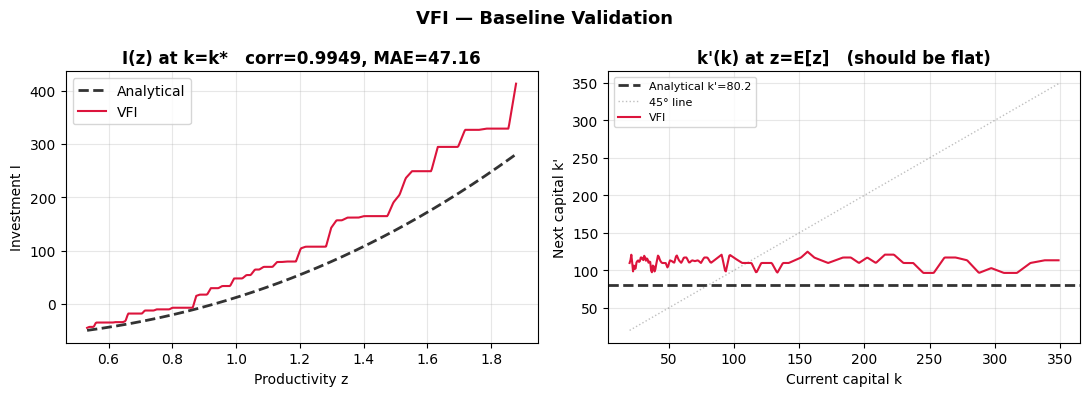

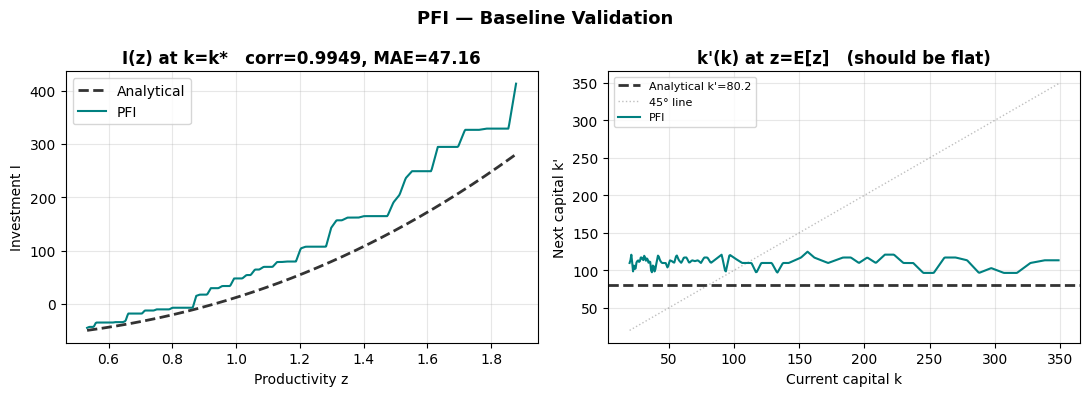

In [9]:
from scipy.interpolate import RegularGridInterpolator


def validate_grid_policy(result, label, color, save_name=None):
    """Two-panel validation for a grid-based VFI/PFI policy.

    Interpolates k'(z, k) from the discrete grid onto the continuous
    evaluation grids used for NN validation.
    """
    exo_grid_1d  = result["grids"]["exo_grids_1d"][0]    # z values
    endo_grid_1d = result["grids"]["endo_grids_1d"][0]    # k values
    # policy_endo: (n_exo, n_endo, 1) -> k'(z, k)
    k_next_grid  = result["policy_endo"][:, :, 0].numpy()  # (n_exo, n_endo)

    # Build interpolator: axes are (z, k) -> k'
    interp = RegularGridInterpolator(
        (exo_grid_1d, endo_grid_1d), k_next_grid,
        method="linear", bounds_error=False, fill_value=None,
    )

    # Panel 1: I(z) at k = k*
    pts_z = np.column_stack([z_grid, np.full(n_grid, k_star)])
    k_next_at_kstar = interp(pts_z)
    I_z = k_next_at_kstar - (1 - baseline_params.delta) * k_star

    # Panel 2: k'(k) at z = E[z]
    pts_k = np.column_stack([np.full(n_grid, z_mean), k_grid])
    k_prime_k = interp(pts_k)

    corr = np.corrcoef(I_z, I_exact_z)[0, 1]
    mae  = np.mean(np.abs(I_z - I_exact_z))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(z_grid, I_exact_z, "k--", lw=2, label="Analytical", alpha=0.8)
    axes[0].plot(z_grid, I_z, color=color, lw=1.5, label=f"{label}")
    axes[0].set_title(f"I(z) at k=k*   corr={corr:.4f}, MAE={mae:.2f}", fontweight="bold")
    axes[0].set_xlabel("Productivity z")
    axes[0].set_ylabel("Investment I")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].axhline(k_prime_ss, color="k", ls="--", lw=2,
                    label=f"Analytical k'={k_prime_ss:.1f}", alpha=0.8)
    axes[1].plot(k_grid, k_grid, ":", color="gray", lw=1, alpha=0.5, label="45\u00b0 line")
    axes[1].plot(k_grid, k_prime_k, color=color, lw=1.5, label=f"{label}")
    axes[1].set_title("k'(k) at z=E[z]   (should be flat)", fontweight="bold")
    axes[1].set_xlabel("Current capital k")
    axes[1].set_ylabel("Next capital k'")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"{label} \u2014 Baseline Validation", fontweight="bold", fontsize=13)
    plt.tight_layout()
    if SAVE_RESULTS and save_name:
        fig.savefig(os.path.join(FIGURES_DIR, f"val_{save_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()


validate_grid_policy(results["vfi"], "VFI", "crimson", save_name="vfi")
validate_grid_policy(results["pfi"], "PFI", "teal", save_name="pfi")

---
# Section 3: Networks

Both networks share the hidden stack: `StaticNormalizer → [Dense + SiLU] × K`.

- **PolicyNetwork**: `s -> a` with affine-rescaled output `center + sqrt(half_range) * raw`, then clip.  
  The center provides a warm-start near the steady-state investment; `sqrt(half_range)` amplifies gradients.
- **StateValueNetwork**: `s -> V(s)` scalar (level space), used by BRM and SHAC.

In [ ]:
def make_policy(env, n_neurons=N_NEURONS, name="policy"):
    net = PolicyNetwork(
        state_dim  = env.state_dim(),
        action_dim = env.action_dim(),
        **env.action_spec(),
        n_layers   = 5,
        n_neurons  = n_neurons,
        name       = name,
    )
    net(tf.zeros((1, env.state_dim())))
    return net


def make_value_net(env, n_neurons=N_NEURONS, name="value_net"):
    net = StateValueNetwork(
        state_dim = env.state_dim(),
        n_layers  = 5,
        n_neurons = n_neurons,
        name      = name,
    )
    net(tf.zeros((1, env.state_dim())))
    return net


_p = make_policy(env, name="_tmp")
print(f"Policy params: {sum(np.prod(v.shape) for v in _p.trainable_variables):,}")
del _p

---
# Section 4: Training

Each trainer receives a pre-built dataset dict and a config dataclass — no RNG, no simulation, no replay buffer inside the trainer.  
The static normalizer is fit once from the full dataset before gradient steps, then frozen.

## 4.1 Lifetime Reward (LR)

Maximizes $\sum_{t=0}^{T-1} \gamma^t r_t + \gamma^T \hat{V}^{\text{term}}$ via BPTT.  
Gradients flow through the endogenous capital trajectory $k_0 \to k_1 \to \cdots \to k_T$.  
The exogenous path $z_0, \ldots, z_T$ is fixed from `train_traj` — no gradient through $z$.

**Terminal value:** $\hat{V}^{\text{term}} = r(\bar{s}, \bar{a}) / (1 - \gamma)$ where $\bar{s} = [k_T \mid \bar{z}]$ uses the stationary exogenous mean $\bar{z} = e^\mu$ and $\bar{a} = \delta k_T$ is the action holding capital constant. This is a fixed formula (no policy call) — gradients flow through $k_T$ but not through the policy at the terminal step.

In [ ]:
lr_config = LRConfig(
    n_steps        = LR_STEPS,
    horizon        = LR_HORIZON,
    terminal_value = True,
    eval_interval  = EVAL_INTERVAL,
)

tf.random.set_seed(MASTER_SEED[0])
policy_lr = make_policy(env, name="policy_lr")

print(f"Training LR: {LR_STEPS} steps, horizon={LR_HORIZON}, "
      f"batch={lr_config.batch_size}, lr={lr_config.policy_optimizer.learning_rate}")
print("=" * 60)
results["lr"] = train_lr(env, policy_lr, train_traj, val_flat, config=lr_config)
print("=" * 60)

## 4.2 Euler Residual (ER)

Minimizes squared Euler equation residuals using the AiO cross-product estimator:
$$L_{ER} = \mathbb{E}[F(z^{\text{main}}_{t+1}) \cdot F(z^{\text{fork}}_{t+1})]$$
Both next-state shock draws come from `train_flat`. A Polyak-averaged target policy provides $a_{t+1}$.

In [ ]:
er_config = ERConfig(
    n_steps       = ER_STEPS,
    eval_interval = EVAL_INTERVAL,
)

tf.random.set_seed(MASTER_SEED[0])
policy_er = make_policy(env, name="policy_er")

print(f"Training ER: {ER_STEPS} steps, loss={er_config.loss_type}, "
      f"batch={er_config.batch_size}, lr={er_config.policy_optimizer.learning_rate}")
print("=" * 60)
results["er"] = train_er(env, policy_er, train_flat, val_flat, config=er_config)
print("=" * 60)

## 4.3 Bellman Residual Minimization (BRM)

Jointly trains $\pi_\theta$ and $V_\phi$:
- $L_{BR} = \mathbb{E}[(V(s) - r - \gamma V(s'))^2 / \lambda^2]$ — trains $V$ only
- $L_{FOC} = \mathbb{E}\left[\left(\partial r/\partial a + \gamma (\partial k'/\partial a)^\top \nabla V\right)^2\right]$ — trains $\pi$ only

`br_scale` $= |V^*(k^*, \bar{z})|$ normalizes the Bellman residual to $O(1)$.

**Warm-start:** Like SHAC, the critic is pre-trained on analytical terminal-value targets for 200 steps before joint training begins, giving $V_\phi$ a reasonable initial shape.

In [ ]:
brm_config = BRMConfig(
    n_steps       = BRM_STEPS,
    br_scale      = 1.0 / env.compute_reward_scale(),  # = |V*(k*, z̄)|
    eval_interval = EVAL_INTERVAL,
    warm_start_steps = 500  # pre-trains V on analytical targets
)

tf.random.set_seed(MASTER_SEED[0])
policy_brm = make_policy(env, name="policy_brm")
value_net  = make_value_net(env, name="value_net")

print(f"Training BRM: {BRM_STEPS} steps, loss={brm_config.loss_type}, "
      f"batch={brm_config.batch_size}, lr={brm_config.policy_optimizer.learning_rate}")
print(f"  br_scale={brm_config.br_scale:.2f}, warm_start={brm_config.warm_start_steps}")
print("=" * 60)
results["brm"] = train_brm(env, policy_brm, value_net, train_flat, val_flat, config=brm_config)
print("=" * 60)

## 4.4 Short-Horizon Actor-Critic (SHAC)

A variant of Xu et al. (2022) adapted for economic environments. Retains SHAC's core structure — h-step actor BPTT through differentiable dynamics with windowed continuation — but replaces the critic with a DDPG-style 1-step Bellman target.

**Architecture:**
- **Actor (h-step BPTT, current π + current V):** Unrolls h steps with the current policy through differentiable dynamics, bootstrapping with the **current** value network $V_\phi(s_h)$. Gradients flow through $\pi_\theta$ and $V_\phi$ into the dynamics chain.
- **Critic (1-step Bellman, target π̄ + target V̄):** For each visited state $s_t$, computes the regression target $y = r(s_t, \bar{\pi}(s_t)) + \gamma \bar{V}(f(s_t, \bar{\pi}(s_t), z_{t+1}))$ using Polyak-averaged target networks. The target $y$ is fully detached (`stop_gradient`).
- **Target networks:** Both $\bar{\pi}$ and $\bar{V}$ are maintained and Polyak-updated each step.

**Key differences from vanilla SHAC (Xu et al., 2022):**
1. Actor bootstrap uses **current V** (not target $\bar{V}$) — richer gradient signal
2. Critic uses **1-step Bellman with target π̄ + target V̄** (not TD-λ with on-policy data) — breaks the positive feedback loop between actor and critic that causes divergence
3. **Cold start** by default (`warm_start_steps=0`) — the h-step actor rollout provides enough exact gradient signal through dynamics that the actor learns correctly even without an accurate initial critic

**Configuration:** Inherits SHAC paper defaults: $h=32$, $B=64$, actor lr $=2\times10^{-3}$, critic lr $=5\times10^{-3}$, $n_{\text{critic}}=16$, $\alpha=0.995$.

**Reward normalization:** Same as vanilla SHAC — `reward_scale` $= 1/|V^*|$ normalizes rewards so $V \approx O(1)$, making the paper hyperparameters stable. Auto-computed by default.

**Compiled training:** Actor rollout and critic update are each wrapped in `@tf.function` with statically-unrolled loops (no TensorArray) for Metal/M1 performance.

In [ ]:
shac_config = SHACConfig(
    n_steps       = SHAC_STEPS,
    eval_interval = EVAL_INTERVAL,
    # reward_scale=None (default) → auto-computed via env.compute_reward_scale()
    # This normalizes V to O(1), making paper hyperparams stable.
    # All other params use defaults from SHACConfig:
    #   h=32, B=64, actor_lr=2e-3, critic_lr=5e-3,
    #   n_critic=16, polyak=0.995, warm_start_steps=0 (cold start)
)

tf.random.set_seed(MASTER_SEED[0])
policy_shac    = make_policy(env, name="policy_shac")
value_net_shac = make_value_net(env, name="value_net_shac")

print(f"Training SHAC: {SHAC_STEPS} steps (windows), h={shac_config.short_horizon}, "
      f"T={shac_config.horizon}, B={shac_config.batch_size}")
print(f"  actor_lr={shac_config.policy_optimizer.learning_rate}, "
      f"critic_lr={shac_config.critic_optimizer.learning_rate}")
print(f"  n_critic={shac_config.n_critic}, "
      f"warm_start={shac_config.warm_start_steps} (cold start)")
print(f"  reward_scale={shac_config.reward_scale} (None=auto)")
print("=" * 60)
results["shac"] = train_shac(env, policy_shac, value_net_shac, train_traj,
                             val_flat, config=shac_config)
print("=" * 60)

---
# Section 5: Validation

Compare all six methods — **VFI, PFI** (grid-based benchmarks) and **LR, ER, BRM, SHAC** (neural network) — against the **frictionless analytical solution**:
$$k'(z) = \left[\frac{\theta \cdot E[z'|z]}{r + \delta}\right]^{\frac{1}{1-\theta}}, \qquad I^*(k, z) = k'(z) - (1-\delta)k$$

Two checks:
1. **I(z) at k = k\***: policy must match the analytical investment schedule (increasing in z)
2. **k'(k) at z = E[z]**: must be flat — $k'$ is independent of $k$ in the frictionless model

In [ ]:
n_grid   = 500
z_grid   = np.linspace(float(env.z_min), float(env.z_max), n_grid)
k_grid   = np.linspace(float(env.k_min), float(env.k_ref), n_grid)
k_star   = float(env.k_star)
z_mean   = float(np.exp(shock_params.mu))

# Analytical benchmarks
k_prime_z  = compute_frictionless_policy(z_grid, baseline_params, shock_params)
I_exact_z  = k_prime_z - (1 - baseline_params.delta) * k_star
k_prime_ss = compute_frictionless_policy(np.array([z_mean]), baseline_params, shock_params)[0]

s_at_kstar = tf.constant(np.column_stack([np.full(n_grid, k_star), z_grid]), dtype=tf.float32)
s_at_zmean = tf.constant(np.column_stack([k_grid, np.full(n_grid, z_mean)]), dtype=tf.float32)


def validate_policy(policy, label, color, save_name=None):
    """Two-panel policy validation against analytical benchmark."""
    I_z = policy(s_at_kstar, training=False).numpy().flatten()
    I_k = policy(s_at_zmean, training=False).numpy().flatten()
    k_prime_k = (1 - baseline_params.delta) * k_grid + I_k

    corr = np.corrcoef(I_z, I_exact_z)[0, 1]
    mae  = np.mean(np.abs(I_z - I_exact_z))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(z_grid, I_exact_z, "k--", lw=2, label="Analytical", alpha=0.8)
    axes[0].plot(z_grid, I_z, color=color, lw=1.5, label=f"{label} (learned)")
    axes[0].set_title(f"I(z) at k=k*   corr={corr:.4f}, MAE={mae:.2f}", fontweight="bold")
    axes[0].set_xlabel("Productivity z")
    axes[0].set_ylabel("Investment I")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].axhline(k_prime_ss, color="k", ls="--", lw=2,
                    label=f"Analytical k'={k_prime_ss:.1f}", alpha=0.8)
    axes[1].plot(k_grid, k_grid, ":", color="gray", lw=1, alpha=0.5, label="45\u00b0 line")
    axes[1].plot(k_grid, k_prime_k, color=color, lw=1.5, label=f"{label} (learned)")
    axes[1].set_title("k'(k) at z=E[z]   (should be flat)", fontweight="bold")
    axes[1].set_xlabel("Current capital k")
    axes[1].set_ylabel("Next capital k'")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"{label} \u2014 Baseline Validation", fontweight="bold", fontsize=13)
    plt.tight_layout()
    if SAVE_RESULTS and save_name:
        fig.savefig(os.path.join(FIGURES_DIR, f"val_{save_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

print("Validation helper ready.")

In [ ]:
validate_policy(results["lr"]["policy"], "LR", "steelblue", save_name="lr")

In [ ]:
validate_policy(results["er"]["policy"], "ER", "darkorange", save_name="er")

In [ ]:
validate_policy(results["brm"]["policy"], "BRM", "seagreen", save_name="brm")

In [ ]:
validate_policy(results["shac"]["policy"], "SHAC", "mediumpurple", save_name="shac")

---
# Section 6: Checkpointing

Save trained models and history under `results/v2-{timestamp}/`.  
The `results/v2-latest` symlink always points to the most recent run.

In [ ]:
import json, dataclasses

if SAVE_RESULTS:
    for method_name, result in results.items():
        method_dir = os.path.join(CHECKPOINTS_DIR, "basic", "baseline", method_name)
        os.makedirs(method_dir, exist_ok=True)

        # Grid-based solvers (VFI/PFI): save arrays instead of Keras models
        if method_name in ("vfi", "pfi"):
            np.savez(os.path.join(method_dir, "solution.npz"),
                     value=result["value"].numpy(),
                     policy_action=result["policy_action"].numpy(),
                     policy_endo=result["policy_endo"].numpy(),
                     prob_matrix=result["prob_matrix"].numpy())
            # Save 1-D grids
            grids_to_save = {f"exo_{i}": g for i, g in enumerate(result["grids"]["exo_grids_1d"])}
            grids_to_save.update({f"endo_{i}": g for i, g in enumerate(result["grids"]["endo_grids_1d"])})
            grids_to_save.update({f"action_{i}": g for i, g in enumerate(result["grids"]["action_grids_1d"])})
            np.savez(os.path.join(method_dir, "grids.npz"), **grids_to_save)
            # Save metadata
            meta = {"converged": result["converged"], "n_iter": result["n_iter"]}
            with open(os.path.join(method_dir, "meta.json"), "w") as f:
                json.dump(meta, f, indent=2)
        else:
            # NN-based methods: save Keras models + history + config
            result["policy"].save(os.path.join(method_dir, "policy.keras"))

            if "value_net" in result:
                result["value_net"].save(os.path.join(method_dir, "value_net.keras"))

            with open(os.path.join(method_dir, "history.json"), "w") as f:
                json.dump(result["history"], f, indent=2)

            with open(os.path.join(method_dir, "config.json"), "w") as f:
                json.dump(dataclasses.asdict(result["config"]), f, indent=2)

        print(f"  Saved {method_name} -> {method_dir}/")

    with open(os.path.join(CHECKPOINTS_DIR, "params.json"), "w") as f:
        json.dump({"econ_params":  dataclasses.asdict(baseline_params),
                   "shock_params": dataclasses.asdict(shock_params)}, f, indent=2)

    print(f"\nAll checkpoints saved to: {CHECKPOINTS_DIR}")
    print(f"Stable path: results/v2-latest/checkpoints/")
else:
    print("SAVE_RESULTS=False: skipping")